In [ ]:
# Environment setup. Run this first, on Colab or locally.
# Colab: Runtime -> Change runtime type -> GPU before running anything else.
#
# On Colab this mounts Google Drive and then works directly out of your Drive
# folder: the .py files are imported from there, and everything this notebook
# writes (latents.pt, embeddings.pt, checkpoints/, previews/) is saved back
# there too, so nothing is lost when the runtime disconnects.
import os
import sys
from pathlib import Path

# TODO: set this to the Drive folder that holds the .py files (scheduler.py, unet.py,
# train.py, sample.py). The path is relative to the root of your Drive, so the default
# below means "My Drive/DDL-Diffusion/code".
DRIVE_PROJECT = "DDL-Diffusion/code"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q diffusers transformers datasets
    from google.colab import drive

    # Asks for authorization the first time it runs in a session; a no-op afterwards.
    drive.mount("/content/drive")

    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.is_dir():
        drive_root = Path("/content/drive/My Drive")   # older Colab naming
    project_dir = drive_root / DRIVE_PROJECT

    if not (project_dir / "scheduler.py").is_file():
        raise RuntimeError(
            f"no scheduler.py under {project_dir} — upload the .py files to that "
            f"folder, or fix DRIVE_PROJECT above"
        )

    # cd into the Drive folder so `from unet import UNet` resolves and every
    # relative path below (latents.pt, checkpoints/, previews/) writes to Drive.
    os.chdir(project_dir)
else:
    # Local kernels don't agree on the starting cwd: Jupyter uses the notebook's
    # own directory, PyCharm/VS Code often use the project root. Walk up until we
    # find code/ so the bare `from scheduler import ...` imports and the relative
    # .pt paths resolve either way.
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        target = base if base.name == "code" else base / "code"
        if (target / "scheduler.py").is_file():
            os.chdir(target)
            break
    else:
        raise RuntimeError(f"couldn't locate the repo's code/ directory from {start}")

# Belt and braces: guarantee cwd is importable even if the kernel was started
# with an empty sys.path[0] (some launchers do this).
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("colab:", IN_COLAB)
print("cwd  :", os.getcwd())

In [1]:
import torch
import datasets
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms as T
from diffusers import AutoencoderKL
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModel


In [2]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
device

'mps'

In [ ]:
SEED = 42   # single source of truth: seeds training and the preview sampler

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

In [4]:
poke_data = datasets.load_dataset("diffusers/pokemon-gpt4-captions")

/Users/markomirkovic/Documents/GitHub/DDL-Diffusion/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
print(poke_data)
print(poke_data["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 833
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1280 at 0x117910750>, 'text': 'A cheerful Bulbasaur ready for its next Pokémon adventure.'}


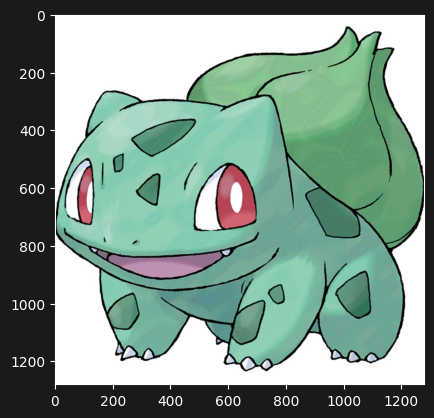

A cheerful Bulbasaur ready for its next Pokémon adventure.


In [6]:
sample = poke_data["train"][0]
plt.imshow(sample["image"])
plt.show()
print(sample["text"])

In [7]:
transforms = T.Compose([
    T.Resize(512),
    T.CenterCrop(512),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess(image):
    # Returns (3, 512, 512). Caller adds batch dim if needed.
    return transforms(image)

test_image = preprocess(sample["image"])
print(test_image.shape)
print(test_image.min(), test_image.max())

torch.Size([3, 512, 512])
tensor(-1.) tensor(1.)


In [8]:
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
vae.requires_grad_(False)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/Users/markomirkovic/Documents/GitHub/DDL-Diffusion/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True, bias=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affin

In [9]:
x = preprocess(poke_data["train"][0]["image"]).unsqueeze(0).to(device)

with torch.no_grad():
    latent = vae.encode(x).latent_dist.sample() * 0.18215

print(latent.shape)
print(latent.min(), latent.max(), latent.mean(), latent.std())

torch.Size([1, 4, 64, 64])
tensor(-2.2723, device='mps:0') tensor(3.0827, device='mps:0') tensor(0.5192, device='mps:0') tensor(0.9315, device='mps:0')


In [10]:
# Encode the WHOLE dataset -> latents.pt
all_latents = []
batch_size = 16

for i in tqdm(range(0, len(poke_data["train"]), batch_size)):
    batch_items = poke_data["train"][i : i + batch_size]
    imgs = torch.stack([preprocess(im) for im in batch_items["image"]]).to(device)
    with torch.no_grad():
        latents = vae.encode(imgs).latent_dist.sample() * 0.18215
    all_latents.append(latents.cpu())  # .cpu() is critical — don't hoard on device

latents_tensor = torch.cat(all_latents, dim=0)
print(latents_tensor.shape)   # expect (~833, 4, 64, 64)
torch.save(latents_tensor, "latents.pt")


100%|██████████| 209/209 [06:53<00:00,  1.98s/it]

torch.Size([833, 4, 64, 64])


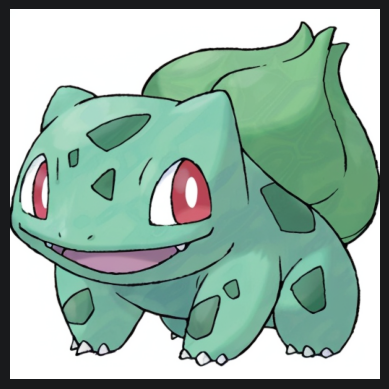

In [11]:
# Decode a saved latent back to an image
latents = torch.load("latents.pt")
one = latents[0:1].to(device) / 0.18215      # undo the scaling
with torch.no_grad():
    decoded = vae.decode(one).sample          # (1, 3, 512, 512), values roughly in [-1, 1]
img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2  # denormalize -> [0, 1]
img = img.permute(1, 2, 0).numpy()             # (H, W, C) for matplotlib
plt.imshow(img); plt.axis("off"); plt.show()

In [12]:
CLIP_NAME = "openai/clip-vit-large-patch14"
tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)
text_encoder = CLIPTextModel.from_pretrained(CLIP_NAME).to(device)
text_encoder.eval()
text_encoder.requires_grad_(False)

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 5458.54it/s]
[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...2

CLIPTextModel(
  (embeddings): CLIPTextEmbeddings(
    (token_embedding): Embedding(49408, 768)
    (position_embedding): Embedding(77, 768)
  )
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      )
    )
  )
  (fina

In [13]:
# Verify shape (1, 77, 768).
test_caption = poke_data["train"][0]["text"]

tokens = tokenizer(
    test_caption,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
)
input_ids = tokens.input_ids.to(device)

with torch.no_grad():
    test_emb = text_encoder(input_ids).last_hidden_state

print(test_emb.shape)
print(test_emb.min(), test_emb.max(), test_emb.mean())

torch.Size([1, 77, 768])
tensor(-28.0912, device='mps:0') tensor(33.0632, device='mps:0') tensor(-0.1118, device='mps:0')


In [14]:
# Encode ALL captions -> embeddings.pt
# Row i of embeddings.pt -> row i of latents.pt.
all_captions = [row["text"] for row in poke_data["train"]]
assert len(all_captions) == latents_tensor.shape[0], "caption count must match latent count"

all_input_ids = tokenizer(
    all_captions,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids

all_embeddings = []
text_batch_size = 32
for i in tqdm(range(0, len(all_captions), text_batch_size)):
    batch_ids = all_input_ids[i : i + text_batch_size].to(device)
    with torch.no_grad():
        emb = text_encoder(batch_ids).last_hidden_state
    all_embeddings.append(emb.cpu())

embeddings_tensor = torch.cat(all_embeddings, dim=0)
print(embeddings_tensor.shape)   # (833, 77, 768)
torch.save(embeddings_tensor, "embeddings.pt")

100%|██████████| 27/27 [00:04<00:00,  5.75it/s]


torch.Size([833, 77, 768])


In [15]:
# Encode the "" -> uncond_embedding.pt
# Used for Classifier-Free Guidance (CFG) during training and inference.
uncond_ids = tokenizer(
    "",
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)

with torch.no_grad():
    uncond_embedding = text_encoder(uncond_ids).last_hidden_state

print(uncond_embedding.shape)   # (1, 77, 768)
torch.save(uncond_embedding.cpu(), "uncond_embedding.pt")

torch.Size([1, 77, 768])


In [1]:
# autoreload makes Jupyter pick up edits to .py files without restarting the kernel.
%load_ext autoreload
%autoreload 2
from scheduler import NoiseScheduler

In [17]:
# alphas_cumprod[-1] should be tiny (well under 0.01). That means by t=T-1, almost no signal survives —
# x_T is essentially pure Gaussian noise, which is what we sample from at inference time.
# If alphas_cumprod[-1] is, say, 0.3, "noise" still has 30% of the
# original signal in it. The model never learns to denoise pure noise,
# and inference produces washed-out replicas instead of new images.

scheduler = NoiseScheduler().to(device)

print("betas                :", scheduler.betas.shape, "on", scheduler.betas.device)
print("alphas_cumprod[0]    =", scheduler.alphas_cumprod[0].item(),  "(should be ~ 1.0)")
print("alphas_cumprod[-1]   =", scheduler.alphas_cumprod[-1].item(), "(should be ~ 0.0)")
print("beta[0]              =", scheduler.betas[0].item())
print("beta[-1]             =", scheduler.betas[-1].item())

betas        : torch.Size([1000]) on mps:0
alphas_cumprod[0]    = 0.9991499781608582 (should be ~ 1.0)
alphas_cumprod[-1]   = 0.0015789627796038985 (should be ~ 0.0)
beta[0]              = 0.0008500000112690032
beta[-1]             = 0.012000000104308128


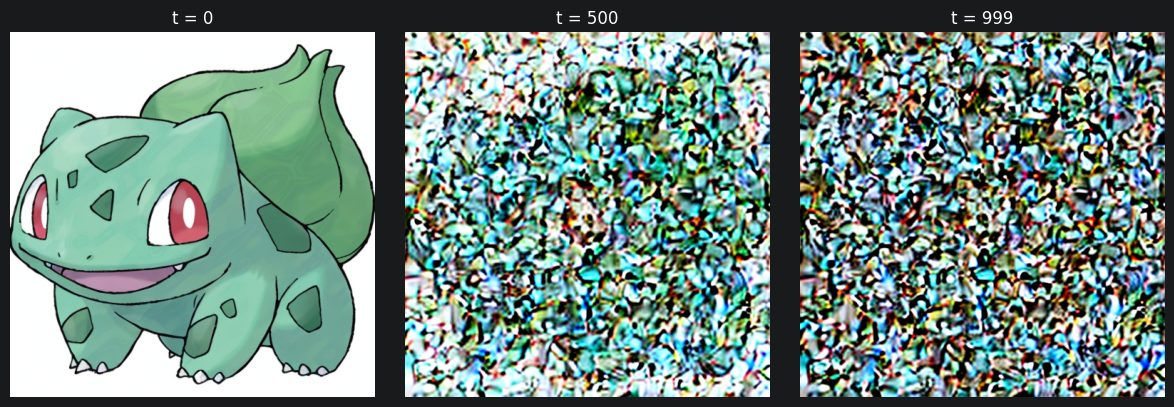

In [18]:
# Noise one real Pokemon latent at three timesteps.
latents = torch.load("latents.pt")
x_0 = latents[0:1].to(device) # (1, 4, 64, 64), already scaled by 0.18215

noise = torch.randn_like(x_0)
timesteps_to_show = [0, 500, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 4))

for ax, t_val in zip(axes, timesteps_to_show):
    # (B,)
    t = torch.full((1,), t_val, device=device, dtype=torch.long)

    # Add noise according to the schedule
    x_t = scheduler.q_sample(x_0, t, noise)

    # Decode back to pixel space
    with torch.no_grad():
        decoded = vae.decode(x_t / 0.18215).sample

    img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2
    img = img.permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(f"t = {t_val}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# Test the U-Net
# What we're checking:
#   1. No shape error
#   2. Output shape matches input shape: (B, 4, 64, 64) in, (B, 4, 64, 64) out.
#   3. Parameter count is in the sane range (low millions).

from unet import UNet
model = UNet().to(device)

B = 2
x = torch.randn(B, 4, 64, 64, device=device)
t = torch.randint(0, 1000, (B,), device=device, dtype=torch.long)
c = torch.randn(B, 77, 768, device=device)

with torch.no_grad():
    out = model(x, t, c)

print("Output shape :", out.shape) # (2, 4, 64, 64)
print("Output dtype :", out.dtype)
print("Output mean  :", out.mean().item())
print("Output std   :", out.std().item())

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")
print(f"Approx size in float32: {n_params * 4 / 1e6:.1f} MB")

Output shape : torch.Size([2, 4, 64, 64])
Output dtype : torch.float32
Output mean  : -0.06499186158180237
Output std   : 0.33301350474357605

Total parameters: 12,658,628
Approx size in float32: 50.6 MB


In [21]:
from torch.utils.data import TensorDataset, DataLoader

latents_tensor = torch.load("latents.pt")             # (833, 4, 64, 64) — VAE-encoded Pokemon
embeddings_tensor = torch.load("embeddings.pt")       # (833, 77, 768)   — CLIP-encoded captions
uncond_embedding = torch.load("uncond_embedding.pt")  # (1, 77, 768)     — CLIP-encoded ""

print("latents   :", latents_tensor.shape, latents_tensor.dtype)
print("embeddings:", embeddings_tensor.shape, embeddings_tensor.dtype)
print("uncond    :", uncond_embedding.shape, uncond_embedding.dtype)

uncond_embedding = uncond_embedding.to(device)
BATCH_SIZE = 4
train_dataset = TensorDataset(latents_tensor, embeddings_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)
print(f"\nbatches per epoch: {len(train_loader)}")

latents   : torch.Size([833, 4, 64, 64]) torch.float32
embeddings: torch.Size([833, 77, 768]) torch.float32
uncond    : torch.Size([1, 77, 768]) torch.float32

batches per epoch: 208


In [ ]:
from train import build_ema, make_optimizer, make_lr_schedule

# Same knobs as code/main.py's CLI flags.
NUM_EPOCHS = 200
WARMUP_STEPS = 1000
LR = 1e-4
WEIGHT_DECAY = 0.01
EMA_DECAY = 0.9999   # lower it (e.g. 0.999) for short runs so the EMA actually tracks the model
EMA_WARMUP = True    # False = fixed EMA_DECAY from step 0, which keeps the EMA near its random init for thousands of steps
AMP = "none"         # "none" | "bf16" | "fp16"  -> "bf16" on a Colab GPU

TOTAL_STEPS = NUM_EPOCHS * len(train_loader)   # used by the LR schedule for cosine decay

model = UNet().to(device)
noise_scheduler = NoiseScheduler().to(device)
ema_model = build_ema(model)
optimizer = make_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
lr_scheduler = make_lr_schedule(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS,
)

amp_dtype = {"none": None, "bf16": torch.bfloat16, "fp16": torch.float16}[AMP]

# fp16 gradients underflow to zero without loss scaling, so fp16 needs a GradScaler.
# bf16 has fp32's exponent range and must NOT use one.
scaler = None
if amp_dtype is torch.float16:
    if device == "cuda":
        scaler = torch.amp.GradScaler("cuda")
        print("fp16: GradScaler enabled")
    else:
        print(f"WARNING: fp16 on {device} has no GradScaler support, so gradients "
              f"will silently underflow. Use AMP = \"bf16\" instead.")

print(f"Trainable params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total steps      : {TOTAL_STEPS:,}  ({NUM_EPOCHS} epochs × {len(train_loader)} batches)")
print(f"Warmup steps     : {WARMUP_STEPS}")
print(f"Peak LR          : {LR}")
print(f"AMP              : {AMP}")

In [ ]:
from train import train_step

smoke_losses = []
data_iter = iter(train_loader)

for i in range(5):
    x_0, context = next(data_iter)
    x_0 = x_0.to(device)
    context = context.to(device)
    loss = train_step(
        model=model,
        ema_model=ema_model,
        noise_scheduler=noise_scheduler,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        x_0=x_0,
        context=context,
        uncond_embedding=uncond_embedding,
        ema_decay=EMA_DECAY,
        amp_dtype=amp_dtype,
        scaler=scaler,
        step=i if EMA_WARMUP else None,
    )
    smoke_losses.append(loss)
    print(f"step {i}: loss = {loss:.4f}")

# Test passed if losses are finite (no NaN) and trending downward.
# Re-run the cell above before real training so the optimizer/LR schedule start clean.

In [ ]:
from pathlib import Path

from tqdm.auto import tqdm
from train import train_step, save_checkpoint, load_checkpoint

# These are relative to cwd, which on Colab is your mounted Drive folder — so
# checkpoints and previews land in Drive and survive a runtime disconnect.
# Checkpoints are ~150 MB each and Drive writes are slow, so keep
# CHECKPOINT_EVERY coarse rather than saving every epoch.
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_EVERY = 25            # save every N epochs
LOG_EVERY = 50                   # update tqdm postfix every N steps
RESUME_PATH = None               # path to a checkpoint .pt, or None to start fresh

PREVIEW = False                  # True -> DDIM sample every PREVIEW_EVERY epochs, so you SEE progress
PREVIEW_EVERY = 10
PREVIEW_STEPS = 50
PREVIEW_CFG = 7.5
PREVIEW_ROW = 0                  # which embedding row to use as the preview prompt
PREVIEW_DIR = "previews"


def make_preview(epoch: int) -> None:
    """One DDIM sample from the EMA model: save a PNG and show it inline."""
    from sample import sample_to_image
    from torchvision.utils import save_image

    # SEED comes from the seeding cell near the top, so previews stay comparable across epochs.
    g = torch.Generator(device=device).manual_seed(SEED)
    img = sample_to_image(
        model=ema_model,
        scheduler=noise_scheduler,
        vae=vae,
        cond_emb=embeddings_tensor[PREVIEW_ROW : PREVIEW_ROW + 1].to(device),
        uncond_emb=uncond_embedding,
        method="ddim",
        guidance_scale=PREVIEW_CFG,
        num_steps=PREVIEW_STEPS,
        generator=g,
    )[0].cpu()   # (3, 512, 512) in [0, 1]

    out_path = Path(PREVIEW_DIR) / f"epoch_{epoch}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    save_image(img, str(out_path))
    print(f"saved preview -> {out_path}")

    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"epoch {epoch}")
    plt.axis("off")
    plt.show()


start_step = 0
start_epoch = 0
loss_history: list[float] = []

if RESUME_PATH is not None:
    start_step, start_epoch, loss_history = load_checkpoint(
        RESUME_PATH, model, ema_model, optimizer, lr_scheduler,
        map_location=device, scaler=scaler,
    )
    model.to(device)
    ema_model.to(device)
    print(f"resumed from {RESUME_PATH}: step={start_step}, epoch={start_epoch}")

global_step = start_step
running_loss = 0.0
running_count = 0

for epoch in range(start_epoch, NUM_EPOCHS):

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for x_0, context in pbar:
        x_0 = x_0.to(device)
        context = context.to(device)

        loss = train_step(
            model=model,
            ema_model=ema_model,
            noise_scheduler=noise_scheduler,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            x_0=x_0,
            context=context,
            uncond_embedding=uncond_embedding,
            ema_decay=EMA_DECAY,
            amp_dtype=amp_dtype,
            scaler=scaler,
            step=global_step if EMA_WARMUP else None,
        )

        loss_history.append(loss)
        running_loss += loss
        running_count += 1
        global_step += 1

        if global_step % LOG_EVERY == 0:
            avg = running_loss / running_count
            pbar.set_postfix(
                loss=f"{avg:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )
            running_loss = 0.0
            running_count = 0

    if (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch + 1 == NUM_EPOCHS:
        ckpt_path = f"{CHECKPOINT_DIR}/epoch_{epoch + 1}.pt"
        save_checkpoint(
            ckpt_path, model, ema_model, optimizer, lr_scheduler,
            step=global_step, epoch=epoch + 1, loss_history=loss_history,
            scaler=scaler,
        )
        print(f"saved checkpoint -> {ckpt_path}")

    if PREVIEW and (epoch + 1) % PREVIEW_EVERY == 0:
        make_preview(epoch + 1)

print("training complete.")

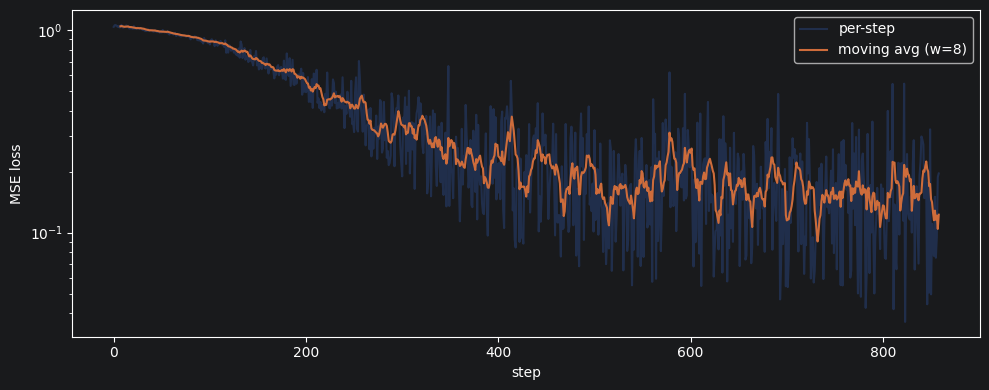

In [25]:
# Plot the loss curve
losses = np.array(loss_history)
window = max(1, len(losses) // 100)
moving = np.convolve(losses, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.25, label="per-step")
plt.plot(np.arange(window - 1, len(losses)), moving, label=f"moving avg (w={window})")

plt.xlabel("step")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()